# Classification - Mini-Project 2

***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name:Jomana Mohamed Magdy

ID:58-4193

Tutorial:10

---

Name:Malak Osama Elmahy

ID:58-3344

Tutorial:10

---


## Dataset Description

The following dataset includes information about loan applicants, including factors such as income, credit score, employment status, loan details, and other indicators of financial stability, along with the final decision showing whether each loan was approved or not.

| Column | Description|
|-|-|
|ApplicationNumber|Unique identifier assigned to each loan application|
|Age|Applicant’s age in years|
|AnnualIncome|Applicant’s yearly income|
|CreditScore|A score representing the applicant’s creditworthiness|
|EmploymentStatus|Applicant’s current employment situation (Employed, Unemployed, Self-Employed)|
|EducationLevel|Highest educational qualification attained (Highschool, Bachelor, Master, Doctorate, Diploma)|
|LoanAmount|Total amount of money requested for the loan|
|LoanDuration|Duration of the loan in months|
|MaritalStatus|Applicant’s marital state (Divorced, Married, Single, Widowed)|
|NumberOfDependents|Number of individuals financially dependent on the applicant|
|HomeOwnershipStatus|Applicant’s housing status (Mortagage, Own, Rent, Other)|
|BankruptcyHistory|Indicates whether the applicant has previously declared bankruptcy (0 = No, 1 = Yes)|
|LoanPurpose|The primary reason for taking the loan (Debt Consolidation, Home Improvement, Education, Personal)|
|PreviousLoanDefaults|Indicates if the applicant has defaulted on any previous loans (0 = No, 1 = Yes)|
|MonthlyLoanPayment|Amount the applicant would need to pay monthly to repay the loan|
|MonthlyIncome|Average monthly income of the applicant|
|JobTenure|Number of years the applicant has been in their current job|
|LoanApproved|Indicates loan approval status (No = Not Approved, Yes = Approved)|

## Importing Libraries & Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#plt.style.use("seaborn")

df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')
df.head()

,ApplicationNumber,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,MonthlyLoanPayment,MonthlyIncome,JobTenure,LoanApproved
0,26231,18,"$26,992.00",586,Employed,Diploma,"$22,432.00",36 months,Single,3,Mortgage,0,Debt Consolidation,0,$623.11,"$2,249.33",3,No
1,13176,18,"$22,825.00",581,Self-Employed,Master,"$30,457.00",24 months,Single,0,Rent,0,Home Improvement,0,"$1,269.04","$1,902.08",5,No
2,27751,18,"$75,891.00",522,Employed,Bachelor,"$30,583.00",96 months,Married,2,Mortgage,0,Personal,0,$318.57,"$6,324.25",6,No
3,20628,18,"$92,094.00",565,Employed,Bachelor,"$72,738.00",36 months,Single,1,Mortgage,0,Vehicle,0,NaN,"$7,674.50",3,No
4,28773,18,"$35,686.00",554,Employed,Diploma,"$28,021.00",36 months,Married,3,Rent,0,Home Improvement,0,$778.36,"$2,973.83",1,No


## Data Inspection

In [9]:
# Basic info
df.info()


# Show first few rows and sample problematic columns
pd.set_option('display.max_columns', None)
df.head(8)


# Check for duplicates
print('duplicates:', df.duplicated().sum())


# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ApplicationNumber             20000 non-null  int64  
 1   Age                           20000 non-null  int64  
 2   AnnualIncome                  20000 non-null  float64
 3   CreditScore                   20000 non-null  int64  
 4   EmploymentStatus              20000 non-null  object 
 5   EducationLevel                20000 non-null  object 
 6   LoanAmount                    20000 non-null  float64
 7   LoanDuration                  0 non-null      float64
 8   MaritalStatus                 20000 non-null  object 
 9   NumberOfDependents            20000 non-null  int64  
 10  HomeOwnershipStatus           20000 non-null  object 
 11  BankruptcyHistory             20000 non-null  int64  
 12  LoanPurpose                   20000 non-null  object 
 13  P

,0
LoanDuration,20000
LoanDuration_raw,20000
LoanApproved_bin,70


## Data Cleaning

In [12]:
import pandas as pd
import numpy as np

# Re-load the DataFrame to ensure a clean state for cleaning
# This assumes the CSV path is consistent, and is a workaround for potential state issues.
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/loan_data.csv')


# Helper to clean numeric strings
def clean_numeric(series):
    s = series.astype(str).str.replace('[,$]', '', regex=True).str.replace(' months', '', regex=False).str.replace(' ', '')
    # remove possible trailing text
    return pd.to_numeric(s.replace({'': np.nan, 'nan': np.nan}), errors='coerce')


# Convert columns
cols_to_clean = ['AnnualIncome','LoanAmount','LoanDuration','MonthlyLoanPayment','MonthlyIncome']
for c in cols_to_clean:
    if c in df.columns:
        df[c+'_raw'] = df[c]
        df[c] = clean_numeric(df[c])


# Convert LoanDuration months if it was expressed in years like '5 years' — we attempt to parse
# (If values are numeric already this will keep them)


# Show conversions
print(df[cols_to_clean].dtypes)


# Imputation
# Categorical: EmploymentStatus -> mode
if 'EmploymentStatus' in df.columns:
    emp_mode = df['EmploymentStatus'].mode().iloc[0]
    df['EmploymentStatus'] = df['EmploymentStatus'].fillna(emp_mode)


# Numeric: median for monthly payment and monthly income
for c in ['MonthlyLoanPayment','MonthlyIncome','AnnualIncome','LoanAmount']:
    if c in df.columns:
        med = df[c].median()
        df[c] = df[c].fillna(med)


# Drop duplicates if any exact duplicates
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)


# Final check
print('After cleaning:')
df.info()
# Create Monthly_Debt_To_Income_Ratio
# Ensure MonthlyIncome not zero
if 'MonthlyIncome' in df.columns:
    df['MonthlyIncome'] = df['MonthlyIncome'].replace(0, np.nan)
    df['Monthly_Debt_To_Income_Ratio'] = df['MonthlyLoanPayment'] / df['MonthlyIncome']
    # If any infinite or NaN (due to zero monthly income) set to large value or median
    df['Monthly_Debt_To_Income_Ratio'] = df['Monthly_Debt_To_Income_Ratio'].replace([np.inf, -np.inf], np.nan)
    df['Monthly_Debt_To_Income_Ratio'] = df['Monthly_Debt_To_Income_Ratio'].fillna(df['Monthly_Debt_To_Income_Ratio'].median())


# Create label column (binary)
df['LoanApproved_bin'] = df['LoanApproved'].map({'Yes':1, 'No':0})


print(df[['MonthlyLoanPayment','MonthlyIncome','Monthly_Debt_To_Income_Ratio','LoanApproved','LoanApproved_bin']].head())

AnnualIncome          float64
LoanAmount            float64
LoanDuration            int64
MonthlyLoanPayment    float64
MonthlyIncome         float64
dtype: object
After cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ApplicationNumber       20000 non-null  int64  
 1   Age                     20000 non-null  int64  
 2   AnnualIncome            20000 non-null  float64
 3   CreditScore             20000 non-null  int64  
 4   EmploymentStatus        20000 non-null  object 
 5   EducationLevel          20000 non-null  object 
 6   LoanAmount              20000 non-null  float64
 7   LoanDuration            20000 non-null  int64  
 8   MaritalStatus           20000 non-null  object 
 9   NumberOfDependents      20000 non-null  int64  
 10  HomeOwnershipStatus     20000 non-null  object 
 11  BankruptcyHistory

## Exploratory Data Analysis

**Q1: On average, which type of educational level has the highest approval rate? Show their order on the graph.**

**Visualization**

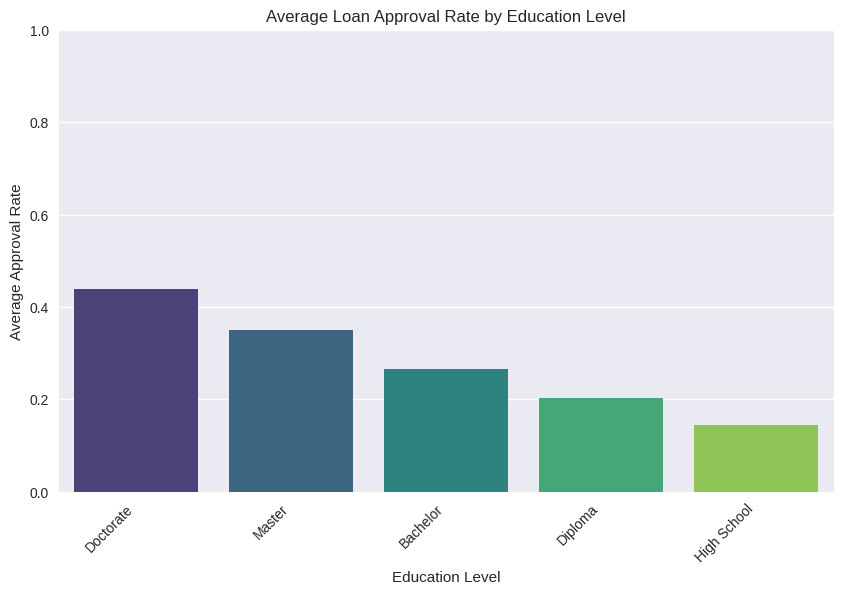

Educational levels by average approval rate (descending):
EducationLevel
Doctorate      0.438226
Master         0.350000
Bachelor       0.265208
Diploma        0.203777
High School    0.143731
Name: LoanApproved_bin, dtype: float64


In [13]:
education_approval_rate = df.groupby('EducationLevel')['LoanApproved_bin'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=education_approval_rate.index, y=education_approval_rate.values, palette='viridis')
plt.title('Average Loan Approval Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Approval Rate')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Approval rate is between 0 and 1
plt.show()

print('Educational levels by average approval rate (descending):')
print(education_approval_rate)

**Answer for Q1**: Your answer here

**Q2: How does the annual income vary among approved applicants? Interpret the values of the 3 quartiles.**

**Visualization**

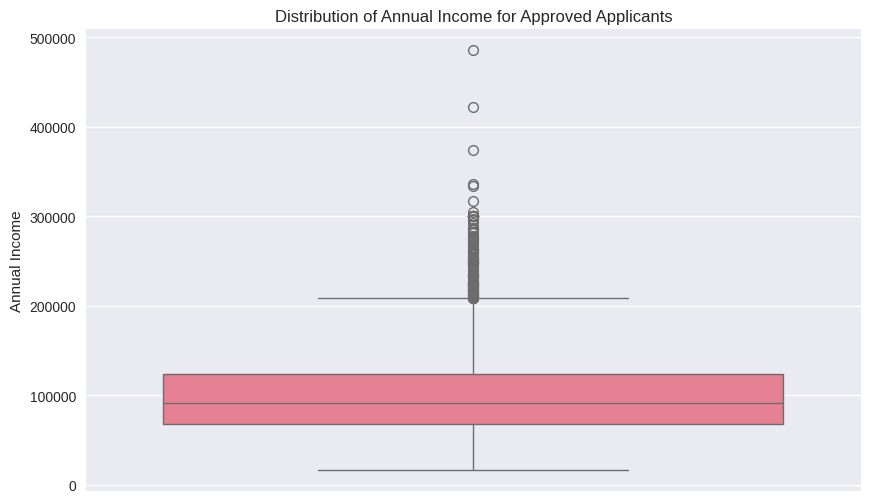


Quartiles of Annual Income for Approved Applicants:
0.25     67367.0
0.50     91274.0
0.75    123816.0
Name: AnnualIncome, dtype: float64


In [14]:
# Filter for approved applicants
approved_applicants = df[df['LoanApproved_bin'] == 1]

# Create a box plot for AnnualIncome of approved applicants
plt.figure(figsize=(10, 6))
sns.boxplot(y=approved_applicants['AnnualIncome'])
plt.title('Distribution of Annual Income for Approved Applicants')
plt.ylabel('Annual Income')
plt.show()

# Calculate the quartiles
quartiles = approved_applicants['AnnualIncome'].quantile([0.25, 0.5, 0.75])
print('\nQuartiles of Annual Income for Approved Applicants:')
print(quartiles)

**Answer for Q2**: Your answer here

**Q3: How does the age of an applicant affect their credit score? (Hint: Use the line of best fit.)**

**Visualization**

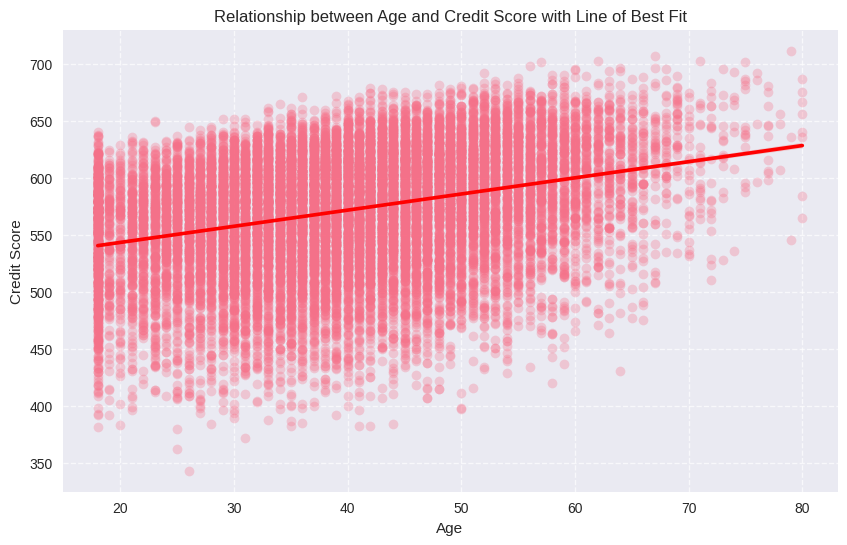

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='CreditScore', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Age and Credit Score with Line of Best Fit')
plt.xlabel('Age')
plt.ylabel('Credit Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Answer for Q3**: Your answer here

**Q4: Is the distribution of applicants' income per month normal or skewed?**

**Visualization**

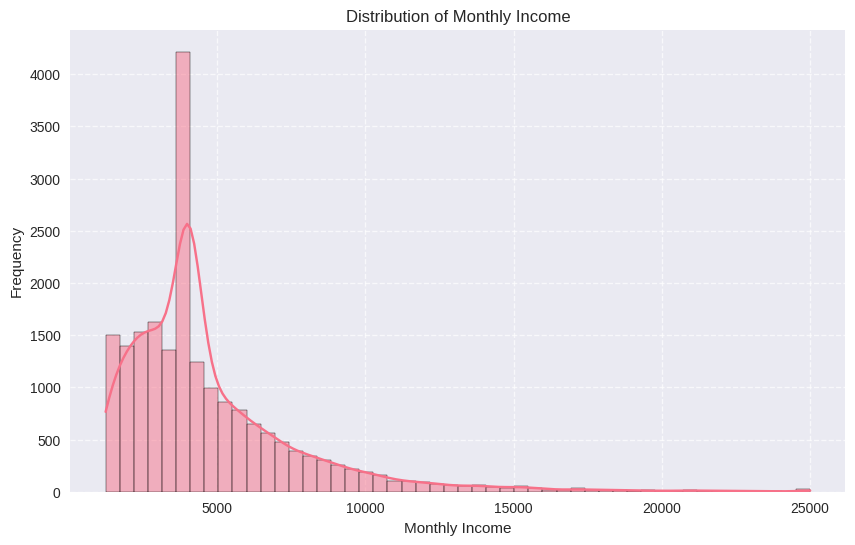

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['MonthlyIncome'], kde=True, bins=50)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Answer for Q4**: Your answer here

## Data Preparation for Modelling

## Modelling

## Evaluation

## Bonus (Optional)